# Modelo de Regresión logística

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import plotly.graph_objects as go
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib

In [2]:
# Carga los datos
df = pd.read_csv('C:/Users/luis_/Desktop\MaestriaEstadisticaAplicada/_11DataViz/Trabajo Fibrosis/fibrosis.csv')
df.head()

,glucemia,urea,creat,colester,trgl,got,gpt,ggt,fa,biltotal,...,alb,na,k,leucos,hcto,plaq,iq,fibrin,fibrosis,sexo
0,158,26,1.6,182,218.0,83,174,52,35,1.7,...,4.7,143,4.7,4730,48.0,88000,100.0,245,0,1
1,112,31,1.5,20,343.0,20,36,42,49,1.1,...,4.0,143,5.0,5380,46.0,147000,100.0,244,0,1
2,79,28,1.5,188,251.0,115,90,133,122,1.2,...,4.9,141,4.7,3600,47.0,99000,100.0,205,0,1
3,103,31,1.3,170,265.0,88,185,108,91,1.1,...,5.3,137,3.9,4460,49.0,104000,100.0,220,0,1
4,126,26,1.3,190,272.0,67,185,96,114,0.8,...,4.8,141,4.4,4550,46.0,73000,100.0,190,0,1


In [3]:
# Transformar los datos 
df['fibrosis'] = df['fibrosis'].map({0: 0, 1: 1, 2: 1, 3:1})
df['sexo'] = df['sexo'].map({1: 'M', 2: 'F'}).astype("category")

df.head()

,glucemia,urea,creat,colester,trgl,got,gpt,ggt,fa,biltotal,...,alb,na,k,leucos,hcto,plaq,iq,fibrin,fibrosis,sexo
0,158,26,1.6,182,218.0,83,174,52,35,1.7,...,4.7,143,4.7,4730,48.0,88000,100.0,245,0,M
1,112,31,1.5,20,343.0,20,36,42,49,1.1,...,4.0,143,5.0,5380,46.0,147000,100.0,244,0,M
2,79,28,1.5,188,251.0,115,90,133,122,1.2,...,4.9,141,4.7,3600,47.0,99000,100.0,205,0,M
3,103,31,1.3,170,265.0,88,185,108,91,1.1,...,5.3,137,3.9,4460,49.0,104000,100.0,220,0,M
4,126,26,1.3,190,272.0,67,185,96,114,0.8,...,4.8,141,4.4,4550,46.0,73000,100.0,190,0,M


In [4]:
# Carga los datos
train_data = pd.read_csv('C:/Users/luis_/Desktop\MaestriaEstadisticaAplicada/_11DataViz/Trabajo Fibrosis/train_fibrosis.csv')
test_data = pd.read_csv('C:/Users/luis_/Desktop\MaestriaEstadisticaAplicada/_11DataViz/Trabajo Fibrosis/test_fibrosis.csv')

In [5]:
train_data["sexo"] = pd.Categorical(train_data["sexo"], categories=["Masculino", "Femenino"])
test_data["sexo"] = pd.Categorical(test_data["sexo"], categories=["Masculino", "Femenino"])

In [6]:
mod1 = smf.logit(
    "fibrosis ~ trgl + got + ggt + prottot + alb + leucos + hcto + plaq + iq + C(sexo)",
    data=train_data
).fit()

print(mod1.summary())

Optimization terminated successfully.
         Current function value: 0.505728
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               fibrosis   No. Observations:                  258
Model:                          Logit   Df Residuals:                      247
Method:                           MLE   Df Model:                           10
Date:                Thu, 16 Oct 2025   Pseudo R-squ.:                  0.2622
Time:                        20:06:33   Log-Likelihood:                -130.48
converged:                       True   LL-Null:                       -176.84
Covariance Type:            nonrobust   LLR p-value:                 1.538e-15
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               7.7371      3.444      2.246      0.025       0.987      14.488
C(

En la siguiente tabla se muestra el resumen del modelo, las variables sexo, triglicéridos, GOT, GGT, Proteínas totales, albúmina, leucocitos, hematocrito, plaquetas e índice de Quick resultaron significativas. Al aumentar los valores de las variables triglicéridos, albúmina, leucocitos, e índice de Quick se disminuyen la probabilidad de presencia de fibrosis, mientras que las otras variables numéricas aumentan esta probabilidad al aumentar su valor. 

**Tabla:** Resultados del modelo de regresión logística

| Variable              | Coeficiente | Error Estándar |     Z   | P-Valor |
|------------------------|-------------|---------------:|--------:|--------:|
| Intercepto             |  7.737      |  3.444         |  2.246  |  0.025  |
| Sexo (Femenino)        | -1.434      |  0.323         | -4.433  |  0.000  |
| Triglicéridos          | -0.003      |  0.002         | -1.666  |  0.096  |
| GOT                    |  0.013      |  0.004         |  3.079  |  0.002  |
| GGT                    |  0.003      |  0.002         |  1.675  |  0.094  |
| Proteínas Totales      |  0.517      |  0.288         |  1.797  |  0.072  |
| Albúmina               | -1.543      |  0.493         | -3.129  |  0.002  |
| Leucocitos             | -0.000      |  0.000         | -1.822  |  0.068  |
| Hematocrito            |  0.071      |  0.040         |  1.775  |  0.076  |
| Plaquetas              |  0.000      |  0.000         |  1.843  |  0.065  |
| Índice de Quick        | -0.079      |  0.027         | -2.959  |  0.003  |

De acuerdo con la métrica de Exactitud del modelo, se obtiene que el modelo clasifica de manera correcta un 71.9% de las observaciones. Según la sensibilidad, el modelo tiene una probabilidad del 72.2% de predecir correctamente a los pacientes con fibrosis. De acuerdo con la especificidad, el modelo predice a los pacientes con ausencia de fibrosis correctamente un 71.4% de las veces. 

**Tabla:** Métricas de desempeño del modelo

| Métrica         | Valor |
|-----------------|-------|
| Exactitud       | 0.719 |
| Sensibilidad    | 0.722 |
| Especificidad   | 0.714 |
| AUC             | 0.738 |

In [115]:
# --- Odds Ratios e intervalos de confianza ---
OR = np.exp(mod1.params)
IC = np.exp(mod1.conf_int())
print("\nOR:\n", OR)
print("\nIC:\n", IC)


OR:
 Intercept              2291.788965
C(sexo)[T.Femenino]       0.238385
trgl                      0.996917
got                       1.012972
ggt                       1.003159
prottot                   1.676893
alb                       0.213744
leucos                    0.999810
hcto                      1.073901
plaq                      1.000008
iq                        0.924143
dtype: float64

IC:
                             0             1
Intercept            2.682048  1.958316e+06
C(sexo)[T.Femenino]  0.126458  4.493777e-01
trgl                 0.993303  1.000544e+00
got                  1.004697  1.021316e+00
ggt                  0.999464  1.006867e+00
prottot              0.954096  2.947261e+00
alb                  0.081322  5.617948e-01
leucos               0.999605  1.000014e+00
hcto                 0.992584  1.161881e+00
plaq                 1.000000  1.000016e+00
iq                   0.877091  9.737196e-01


A continuación, se muestra la curva de ROC y la matriz de confusión del modelo. El área bajo la curva de ROC fue de 0.738. El punto de corte que maximiza el índice de Youden es 0.485, la matriz de confusión del modelo se realizó usando este punto de corte. 

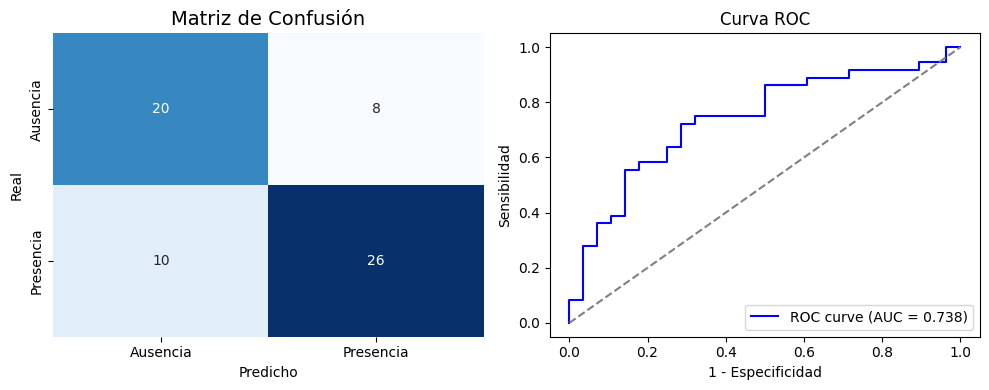

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Probabilidades en el conjunto de prueba
prob1 = mod1.predict(test_data)

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(test_data["fibrosis"], prob1)

# AUC
auc = roc_auc_score(test_data["fibrosis"], prob1)
#print("AUC:", auc)

# Graficar curva ROC
axes[1].plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--")  # línea diagonal
axes[1].set_xlabel("1 - Especificidad")
axes[1].set_ylabel("Sensibilidad")
axes[1].set_title("Curva ROC")
axes[1].legend(loc="lower right")

# --- Mejor punto de corte (Youden index) ---
sens_spec = tpr + (1 - fpr)
idx_max = np.argmax(sens_spec)
cutoff = thresholds[idx_max]

# Binarizar predicciones con el mejor cutoff
predicciones = (prob1 >= cutoff).astype(int)

# Matriz de confusión
cm = confusion_matrix(test_data["fibrosis"], predicciones)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Ausencia", "Presencia"],
            yticklabels=["Ausencia", "Presencia"], ax=axes[0])
axes[0].set_title("Matriz de Confusión", fontsize=14)
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")

plt.tight_layout()
plt.show()

In [9]:
# --- Mejor punto de corte (Youden index) ---
sens_spec = tpr + (1 - fpr)
idx_max = np.argmax(sens_spec)
cutoff = thresholds[idx_max]

print(f"Mejor punto de corte: {cutoff:.3f}")

Mejor punto de corte: 0.485


In [10]:
# Binarizar predicciones con el mejor cutoff
predicciones = (prob1 >= cutoff).astype(int)

# Matriz de confusión
cm = confusion_matrix(test_data["fibrosis"], predicciones)
print("Matriz de confusión:")
print(cm)

Matriz de confusión:
[[20  8]
 [10 26]]


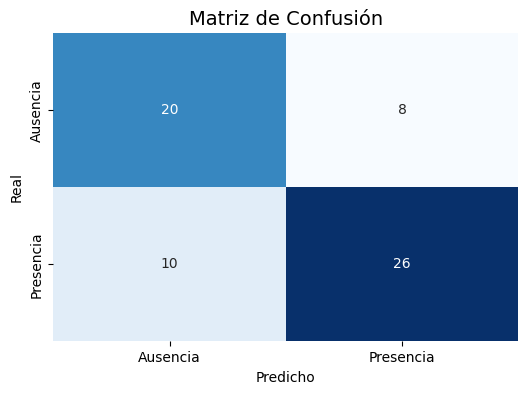

In [17]:
cm = confusion_matrix(test_data["fibrosis"], predicciones)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Ausencia", "Presencia"],
            yticklabels=["Ausencia", "Presencia"])
plt.title("Matriz de Confusión", fontsize=14)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()